### Agentic RAG

In [39]:
# import os
# from dotenv import load_dotenv
# load_dotenv()

# os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [40]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
#from langchain_openai import OpenAIEmbeddings
from langchain_ollama import OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [41]:
urls=[
    "https://langchain-ai.github.io/langgraph/tutorials/introduction/",
    "https://langchain-ai.github.io/langgraph/tutorials/workflows/",
    "https://langchain-ai.github.io/langgraph/how-tos/map-reduce/"
]

docs=[WebBaseLoader(url).load() for url in urls]
docs


[[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')],
 [Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n')]]

In [42]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Add alll these text to vectordb

embeddings = OllamaEmbeddings(
    model="nomic-embed-text",   # required
    # base_url="http://localhost:11434",  # optional if default Ollama host
)

vectorstore = FAISS.from_documents(
    documents=doc_splits,
    embedding=embeddings,
)


retriever=vectorstore.as_retriever()

In [43]:
retriever.invoke("what is langgraph")

[Document(id='5fa3c52c-049b-4db0-929f-938a1b852781', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='0e0ec1da-7c32-481d-92fa-6a8dcd92719a', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/workflows/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 Document(id='040c17e3-f632-46e0-b954-294fd45ce8b7', metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/map-reduce/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...')]

In [44]:
### Retriever To Retriever Tools
from langchain_core.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",
    "Search and return information about LangGraph"
)

In [45]:
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search and return information about LangGraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x000001E67F361800>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x000001E67F3620C0>)

### Langchain Blogs- Seperate Vector Store


In [46]:
langchain_urls=[
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/tutorials/chatbot/",
    "https://python.langchain.com/docs/tutorials/qa_chat_history/"
]

docs=[WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://python.langchain.com/docs/tutorials/', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain is an open source framework with a pre-built agent architecture and integrations for any model or tool — so you can build agents that adapt as fast as the ecosystem evolves', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainSkip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareAdvanced usageGuardrailsRuntimeContext engineeringModel Context Protocol (MCP)Human-in-the-loopMulti-agentRetrievalLong-term memoryAgent developmentLangSmith StudioTestAgent Chat UIDeploy wit

In [47]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
)

doc_splits = text_splitter.split_documents(docs_list)

embeddings = OllamaEmbeddings(model="nomic-embed-text")

vectorstorelangchain = FAISS.from_documents(
    documents=doc_splits,
    embedding=embeddings,
)

retrieverlangchain = vectorstorelangchain.as_retriever()

In [48]:
from langchain_core.tools.retriever import create_retriever_tool

retriever_tool_langchain = create_retriever_tool(
    retrieverlangchain,
    "retriever_vector_langchain_blog",
    "Search and return information about LangChain",
)

In [49]:
tools=[retriever_tool,retriever_tool_langchain]

### LangGraph Workflow

In [50]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [51]:
#from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama


#llm=ChatGroq(model="qwen-qwq-32b")
llm=ChatOllama(model="qwen2.5:7b")
llm.invoke("Hi")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-20T05:16:07.6598396Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8381722300, 'load_duration': 7024264300, 'prompt_eval_count': 30, 'prompt_eval_duration': 507984100, 'eval_count': 10, 'eval_duration': 835449900, 'logprobs': None, 'model_name': 'qwen2.5:7b', 'model_provider': 'ollama'}, id='lc_run--019c7979-ebab-75c2-b236-4e06e83b0dcf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 30, 'output_tokens': 10, 'total_tokens': 40})

In [52]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    #model = ChatGroq(model="qwen-qwq-32b")
    model = ChatOllama(model="qwen2.5:7b")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [53]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

from pydantic import BaseModel, Field

In [54]:
### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    #model = ChatGroq(model="qwen-qwq-32b")
    model = ChatOllama(model="qwen2.5:7b")

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [55]:
from langchain_classic import hub

def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    #llm = ChatGroq(model="qwen-qwq-32b")
    llm = ChatOllama(model="qwen2.5:7b")

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [56]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    #model = ChatGroq(model="qwen-qwq-32b")
    model = ChatOllama(model="qwen2.5:7b")
    response = model.invoke(msg)
    return {"messages": [response]}

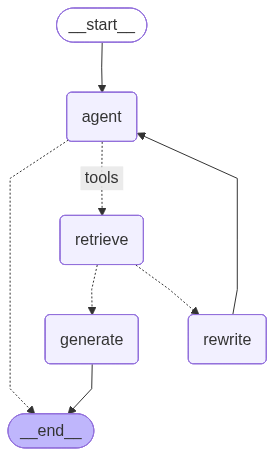

In [57]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool,retriever_tool_langchain])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [58]:
graph.invoke({"messages":"What is Langgraph?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---


{'messages': [HumanMessage(content='What is Langgraph?', additional_kwargs={}, response_metadata={}, id='8e503080-92bb-44f5-88a6-6303a1d6cb7c'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-20T05:16:11.3143381Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3255838300, 'load_duration': 140570900, 'prompt_eval_count': 218, 'prompt_eval_duration': 454869600, 'eval_count': 32, 'eval_duration': 2626288300, 'logprobs': None, 'model_name': 'qwen2.5:7b', 'model_provider': 'ollama'}, id='lc_run--019c797a-0df6-72f0-a0f7-4e80fa9a77ee-0', tool_calls=[{'name': 'retriever_vector_db_blog', 'args': {'query': 'Langgraph'}, 'id': 'a13eb79f-1f46-4790-a961-29f96ab0b49b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 218, 'output_tokens': 32, 'total_tokens': 250}),
  ToolMessage(content='Redirecting...\n\n\n\n\n\n\nRedirecting...\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\nRedirecting...\n\n\n\

In [59]:
graph.invoke({"messages":"What is Langchain?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS NOT RELEVANT---
no
---TRANSFORM QUERY---
---CALL AGENT---


{'messages': [HumanMessage(content='What is Langchain?', additional_kwargs={}, response_metadata={}, id='426eb566-bc18-4cef-bc70-aa4f5ace45c7'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-20T05:16:39.027564Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2756206500, 'load_duration': 119149600, 'prompt_eval_count': 218, 'prompt_eval_duration': 223525300, 'eval_count': 29, 'eval_duration': 2384464300, 'logprobs': None, 'model_name': 'qwen2.5:7b', 'model_provider': 'ollama'}, id='lc_run--019c797a-7c2e-7c20-9c31-6e1c249272f0-0', tool_calls=[{'name': 'retriever_vector_langchain_blog', 'args': {'query': 'What is Langchain?'}, 'id': 'c85ddfc5-e76f-40de-ab07-147ba0ab9bb5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 218, 'output_tokens': 29, 'total_tokens': 247}),
  ToolMessage(content="Copy================================ Human Message =================================\n\nWhat is th

In [60]:
graph.invoke({"messages":"What is Machine learning?"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is Machine learning?', additional_kwargs={}, response_metadata={}, id='5b97f0a2-727a-40fd-a7a1-03eea2ee7232'),
  AIMessage(content='Machine learning is a subset of artificial intelligence that involves developing algorithms and statistical models which enable computer systems to improve their performance on a specific task through experience or data, without being explicitly programmed. In simpler terms, it allows software applications to learn from the data and identify patterns and make decisions with minimal human intervention.\n\nWould you like more detailed information or examples related to machine learning?', additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-20T05:17:20.7487008Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7047326400, 'load_duration': 135170100, 'prompt_eval_count': 218, 'prompt_eval_duration': 362739600, 'eval_count': 75, 'eval_duration': 6404442900, 'logprobs': None, 'mod